# Informe interno

## Imports:

In [1]:
import pandas as pd
import seaborn as sns
from neo4j import GraphDatabase
from pymongo import MongoClient
import matplotlib.pyplot as plt
import os
from itables import show

In [2]:
NEO_URI = "bolt://localhost:7687"
NEO_USER = "neo4j"
NEO_PASS = "test1234"
MONGO_URI = "mongodb://localhost:27017"
MONGO_DB_NAME = "darkweb_tfg"

In [3]:
neo_driver = None
mongo_client = None

In [4]:
def get_mongo_connection():
    global mongo_client
    if mongo_client is None:
        try:
            mongo_client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
            mongo_client.admin.command('ismaster')
            print("Conexión a MongoDB exitosa.")
        except Exception as e:
            print(f"Error al conectar a MongoDB: {e}")
            mongo_client = None
    return mongo_client

In [5]:
def get_neo_driver():
    global neo_driver
    if neo_driver is None:
        try:
            neo_driver = GraphDatabase.driver(
                NEO_URI, 
                auth=(NEO_USER, NEO_PASS), 
                encrypted=False, 
                connection_timeout=5.0
            )
            neo_driver.verify_connectivity()
            print("Conexión a Neo4j exitosa.")
        except Exception as e:
            print(f"Error al conectar a Neo4j: {e}")
            neo_driver = None
    return neo_driver

In [6]:
get_neo_driver()

Conexión a Neo4j exitosa.


In [7]:
get_mongo_connection()

Conexión a MongoDB exitosa.


MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True, serverselectiontimeoutms=5000)

Con este código vamos a ver la cantidad de nodos y de relaciones que tenemos dentro del Neo4J

In [9]:
if neo_driver:
    session = neo_driver.session()
    
    # Consulta para contar todos los nodos y relaciones
    query_counts = """
    CALL db.labels() YIELD label AS node_type
    RETURN node_type, size(nodes(shortestPath((n)-[*]->(n)))) AS count
    UNION ALL
    CALL db.relationshipTypes() YIELD relationshipType AS node_type
    RETURN relationshipType, count(r) AS count
    """ 
    node_counts = session.run("""
    MATCH (n)
    RETURN labels(n) AS node_labels, count(n) AS count
    """)
    rel_counts = session.run("""
    MATCH ()-[r]->()
    RETURN type(r) AS rel_type, count(r) AS count
    """)
    
    data_nodes = {}
    for record in node_counts:
        label = ":".join(record["node_labels"]) 
        data_nodes[label] = record["count"]

    data_rels = {record["rel_type"]: record["count"] for record in rel_counts}

    print("--- Conteo de Nodos ---")
    for k, v in data_nodes.items():
        print(f"Nodos '{k}': {v}")
        
    print("\n--- Conteo de Relaciones ---")
    for k, v in data_rels.items():
        print(f"Relaciones '{k}': {v}")

--- Conteo de Nodos ---
Nodos 'Page': 1689
Nodos 'Term': 8
Nodos 'Synonym': 33
Nodos 'Page:Seed': 1611321

--- Conteo de Relaciones ---
Relaciones 'IS_SYNONYM_OF': 41
Relaciones 'MENTIONS': 377921
Relaciones 'LINKS_TO': 1830529


Con esto se ve el total de nodos que hay en Neo4J, para ver también cuantos de ellos tienen información completa y cuantos no.

In [10]:
def imprimir_resumen_calidad_total():
    try:
        # Consulta NEO
        query = """
        MATCH (p:Page)
        WITH p,
             (p.title IS NOT NULL AND size(trim(toString(p.title))) > 0 AND
              p.text IS NOT NULL AND size(trim(toString(p.text))) > 0) as es_completo
        RETURN 
            count(p) as total,
            sum(CASE WHEN es_completo THEN 1 ELSE 0 END) as completos,
            sum(CASE WHEN NOT es_completo THEN 1 ELSE 0 END) as incompletos
        """
        
        with neo_driver.session() as session:
            res = session.run(query).single()
        
        if not res or res['total'] == 0:
            print("No hay datos en los nodos :Page para analizar.")
            return

        total = res['total']
        completos = res['completos']
        incompletos = res['incompletos']
        pct_ok = (completos / total) * 100
        pct_ko = (incompletos / total) * 100

        print("\n" + "="*40)
        print("📊 AUDITORÍA DE INTEGRIDAD DEL DATASET")
        print("="*40)
        print(f"Total de nodos analizados: {total:,}")
        print(f"---")
        print(f"✅ Información Completa:   {completos:,} ({pct_ok:.1f}%)")
        print(f"❌ Información Incompleta: {incompletos:,} ({pct_ko:.1f}%)")
        print("="*40)

    except Exception as e:
        print(f"❌ Error al obtener los datos: {e}")

imprimir_resumen_calidad_total()


📊 AUDITORÍA DE INTEGRIDAD DEL DATASET
Total de nodos analizados: 1,613,010
---
✅ Información Completa:   125,232 (7.8%)
❌ Información Incompleta: 1,487,778 (92.2%)


Analizando campo 'origins' en la colección 'Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'darkweb_tfg'), 'seeds')'...


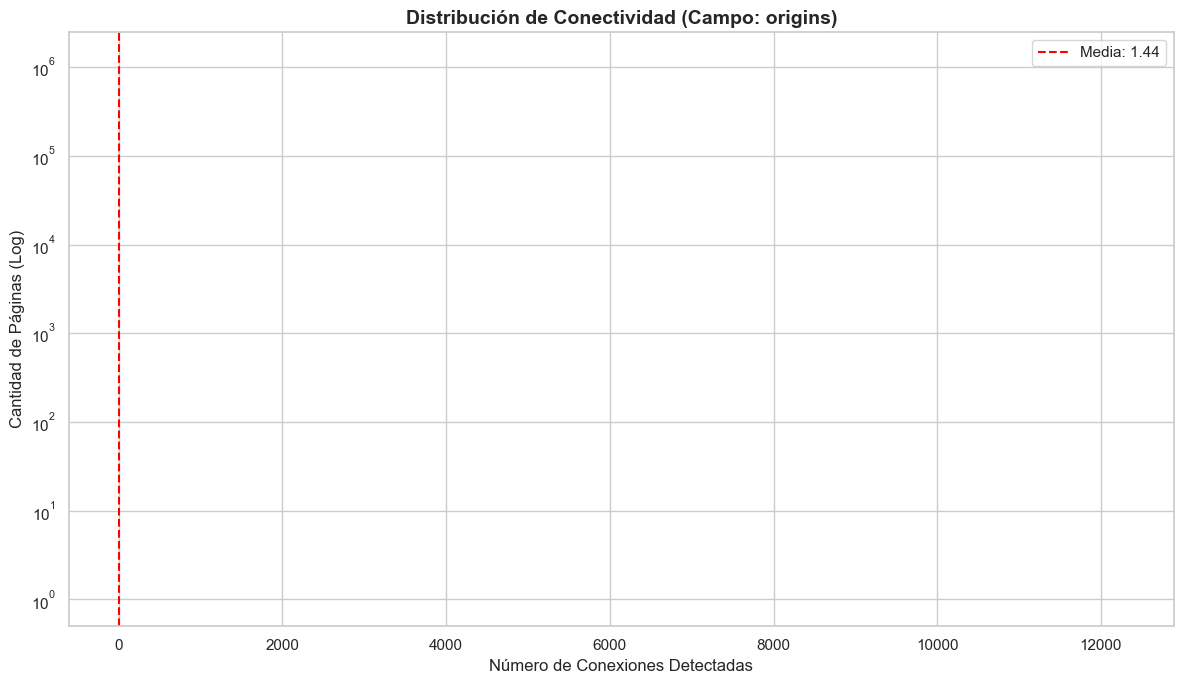

Total documentos: 1613031
Máximo de conexiones en una página: 12277


In [11]:
def plot_expansion_from_origins():
    client = MongoClient(MONGO_URI)
    db = client[MONGO_DB_NAME]
    collection = db['seeds']

    # Cambiamos 'links' por 'origins' que es el campo real que tienes
    pipeline = [
        {
            "$project": {
                "num_links": { 
                    "$cond": {
                        "if": { "$isArray": "$origins" },
                        "then": { "$size": "$origins" },
                        "else": 0
                    }
                }
            }
        }
    ]

    try:
        print(f"Analizando campo 'origins' en la colección '{collection}'...")
        cursor = collection.aggregate(pipeline)
        df = pd.DataFrame(list(cursor))

        if df.empty or df['num_links'].sum() == 0:
            print("El campo 'origins' está vacío o no es un array. Verificando 'detected'...")
            # Si 'origins' no funciona, probamos con 'detected' que también suena a enlaces
            return

        # Visualización profesional para TFG
        plt.figure(figsize=(12, 7))
        sns.set_theme(style="whitegrid")

        # Escala logarítmica para que se vea algo más que la primera barra
        sns.histplot(
            data=df,
            x='num_links',
            bins=range(0, df['num_links'].max() + 2),
            color='#38B2AC',
            edgecolor='black',
            log_scale=(False, True) 
        )

        mean_val = df['num_links'].mean()
        plt.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')

        plt.title('Distribución de Conectividad (Campo: origins)', fontsize=14, fontweight='bold')
        plt.xlabel('Número de Conexiones Detectadas', fontsize=12)
        plt.ylabel('Cantidad de Páginas (Log)', fontsize=12)
        plt.legend(loc="upper right")

        plt.tight_layout()
        plt.show()

        print(f"Total documentos: {len(df)}")
        print(f"Máximo de conexiones en una página: {df['num_links'].max()}")

    except Exception as e:
        print(f"Error: {e}")
    finally:
        client.close()

plot_expansion_from_origins()

In [12]:
import pandas as pd
from pymongo import MongoClient
from IPython.display import display, HTML

# --- CONFIGURACIÓN ---
MONGO_URI = "mongodb://localhost:27017"
MONGO_DB_NAME = "darkweb_tfg"  # Asegúrate de que este es el nombre correcto

def ver_estado_seeds_mongo():
    print("🕵️‍♂️ Conectando a MongoDB para auditar la colección 'seeds'...")
    
    try:
        # 1. Conexión
        client = MongoClient(MONGO_URI)
        db = client[MONGO_DB_NAME]
        seeds_collection = db['seeds']
        
        # 2. Obtención de Conteos (Queries)
        # Total absoluto de semillas en la base de datos
        total_seeds = seeds_collection.count_documents({})
        
        # a) Procesadas Correctamente
        processed = seeds_collection.count_documents({'status': 'ingested'})
        
        # b) Pendientes de visitar
        pending = seeds_collection.count_documents({'status': 'pending'})
        
        # c) Descartadas por contenido corto (Basura/Vacías)
        short_content = seeds_collection.count_documents({
            'status': 'discarded', 
            'discard_reason': 'too_short_content'
        })
        
        # d) Fallidas permanentemente (404, Offline, Timeout)
        failed = seeds_collection.count_documents({'status': 'failed_perm'})
        
        # e) Otros descartes (idioma, duplicado, etc.)
        # Calculamos el resto para que los números cuadren
        otros_descartes = total_seeds - (processed + pending + short_content + failed)

        # 3. Creación del DataFrame para visualizar
        df_estado = pd.DataFrame({
            'Estado / Motivo': [
                '✅ Procesados (Ingested)', 
                '⏳ Pendientes', 
                '🗑️ Descartados (Contenido Corto)', 
                '❌ Fallidos (Offline/Error)',
                '⚠️ Otros Descartes',
                '--- TOTAL ---'
            ],
            'Cantidad': [
                processed, 
                pending, 
                short_content, 
                failed,
                otros_descartes,
                total_seeds
            ]
        })

        # Añadimos columna de Porcentaje
        df_estado['Porcentaje'] = (df_estado['Cantidad'] / total_seeds * 100).round(2).astype(str) + '%'
        
        # Ajustamos el porcentaje del total para que quede limpio
        df_estado.iloc[-1, df_estado.columns.get_loc('Porcentaje')] = '100%'

        # 4. Visualización Bonita en Jupyter
        print(f"\n📊 ESTADO ACTUAL DEL CRAWLER (Base de datos: {MONGO_DB_NAME})")
        
        # Estilo CSS para la tabla
        estilo = [
            dict(selector="th", props=[("font-size", "14px"), ("text-align", "left"), ("background-color", "#f0f2f6")]),
            dict(selector="td", props=[("font-size", "14px"), ("padding", "10px")])
        ]
        
        # Mostramos la tabla coloreada
        display(df_estado.style.set_table_styles(estilo).background_gradient(cmap='Blues', subset=['Cantidad']))

        return df_estado

    except Exception as e:
        print(f"❌ Error conectando a Mongo: {e}")
        return None

# --- EJECUTAR ---
df_resultado = ver_estado_seeds_mongo()

🕵️‍♂️ Conectando a MongoDB para auditar la colección 'seeds'...

📊 ESTADO ACTUAL DEL CRAWLER (Base de datos: darkweb_tfg)


,Estado / Motivo,Cantidad,Porcentaje
0,✅ Procesados (Ingested),125250,7.76%
1,⏳ Pendientes,1413630,87.64%
2,🗑️ Descartados (Contenido Corto),28333,1.76%
3,❌ Fallidos (Offline/Error),45818,2.84%
4,⚠️ Otros Descartes,0,0.0%
5,--- TOTAL ---,1613031,100%


In [13]:
def diagnostico_neo(neo_driver):
    print("🧮 Contando páginas en la base de datos...")
    
    with neo_driver.session() as session:
        # 1. Cuenta TOTAL de nodos (bolas) de tipo Page
        result_total = session.run("MATCH (p:Page) RETURN count(p) as total")
        total_nodos = result_total.single()['total']
        
        # 2. Cuenta URLs ÚNICAS (direcciones distintas)
        result_unicas = session.run("MATCH (p:Page) RETURN count(DISTINCT p.url) as unicas")
        urls_unicas = result_unicas.single()['unicas']
        
        print("\n" + "="*40)
        print(f"📊 RESULTADO DE LA AUDITORÍA:")
        print("="*40)
        print(f"🔵 Total de Nodos 'Page':   {total_nodos:,}")
        print(f"✨ URLs Únicas reales:     {urls_unicas:,}")
        
        diferencia = total_nodos - urls_unicas
        
        if diferencia > 0:
            print(f"⚠️ ¡ALERTA! Tienes {diferencia:,} páginas DUPLICADAS.")
            print("   (Esto explica por qué te salían 125.000 en el gráfico)")
        else:
            print("✅ Tu base de datos está limpia. No hay duplicados.")
            
    return total_nodos, urls_unicas

# EJECUCIÓN
total, unicas = diagnostico_neo(neo_driver)

🧮 Contando páginas en la base de datos...

📊 RESULTADO DE LA AUDITORÍA:
🔵 Total de Nodos 'Page':   1,613,010
✨ URLs Únicas reales:     1,613,010
✅ Tu base de datos está limpia. No hay duplicados.


In [9]:
colores_tfg = {
    'drugs':       '#48BB78', 'carding':     '#ECC94B',
    'hacking':     '#0BC5EA', 'ransomware':  '#F56565',
    'weapon':      '#DD6B20', 'marketplace': '#4299E1',
    'phone':       '#A0AEC0', 'fraud':       '#9F7AEA'
}

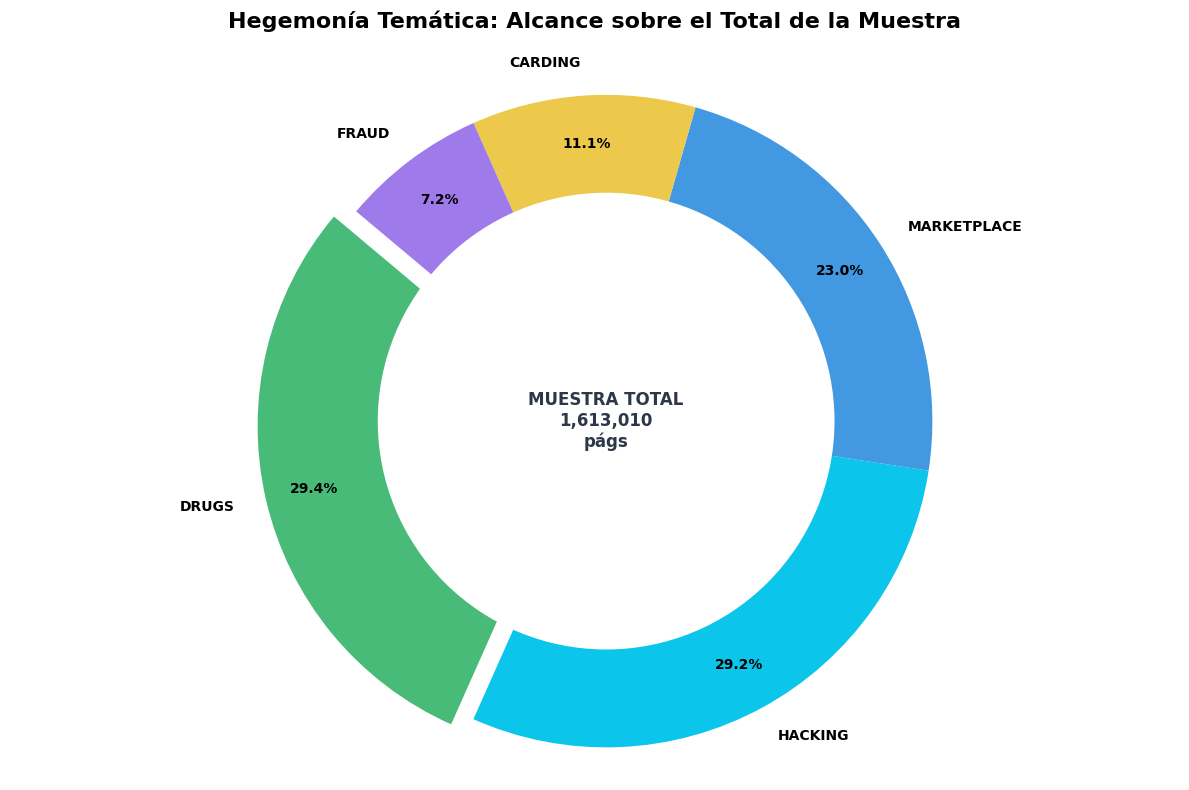


📊 RESUMEN PARA LA MEMORIA:


Loading ITables v2.6.2 from the internet... (need help?)


In [11]:
opt.warn_on_undocumented_option = False

if neo_driver:
    session = neo_driver.session()

    # 1. TOTAL DE PÁGINAS ÚNICAS
    total_pages_query = "MATCH (p:Page) RETURN count(p) AS total"
    total_db_pages = session.run(total_pages_query).single()['total']

    # 2. PÁGINAS POR CADA TÉRMINO
    query_pages = """
    MATCH (root:Term)
    OPTIONAL MATCH (synonym:Synonym)-[:IS_SYNONYM_OF]->(root)
    WITH root, collect(toLower(synonym.name)) + toLower(root.name) AS all_keywords
    OPTIONAL MATCH (p:Page)
    WHERE ANY(word IN all_keywords WHERE toLower(p.text) CONTAINS toLower(word))
    RETURN root.name AS term_name, COUNT(DISTINCT p) AS page_count
    """
    
    df_res = pd.DataFrame(session.run(query_pages).data())
    session.close()

    # 3. CÁLCULO DE ALCANCE
    df_res = df_res.sort_values(by='page_count', ascending=False)
    df_res['Alcance (%)'] = (df_res['page_count'] / total_db_pages) * 100
    top_5 = df_res.head(5).copy()
    
    # --- VISUALIZACIÓN ---
    plt.figure(figsize=(12, 8))
    # Asegúrate de tener 'colores_tfg' definido; si no, el default es gris oscuro
    colores_pie = [colores_tfg.get(x.lower(), '#2D3748') for x in top_5['term_name']]
    
    patches, texts, autotexts = plt.pie(
        top_5['Alcance (%)'], 
        labels=top_5['term_name'].str.upper(),
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colores_pie,
        pctdistance=0.85,
        explode=[0.07] + [0]*4,
        textprops={'fontweight': 'bold', 'fontsize': 10}
    )

    # --- CORRECCIÓN DEL CÍRCULO CENTRAL (DONUT) ---
    centre_circle = plt.Circle((0,0), 0.70, fc='white', linewidth=0)
    plt.gca().add_artist(centre_circle)

    # Texto central
    plt.text(0, 0, f'MUESTRA TOTAL\n{total_db_pages:,}\npágs', 
              ha='center', va='center', fontsize=12, fontweight='bold', color='#2d3748')

    plt.title('Hegemonía Temática: Alcance sobre el Total de la Muestra', fontsize=16, fontweight='bold', pad=25)
    plt.axis('equal') 
    plt.tight_layout()
    
    # Guardado
    os.makedirs('Graficas', exist_ok=True)
    plt.savefig('Graficas/donut_alcance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- TABLA ALARGADA Y ALINEADA A LA IZQUIERDA ---
    print("\n📊 RESUMEN PARA LA MEMORIA:")
    df_memoria = top_5[['term_name', 'page_count', 'Alcance (%)']].copy()
    df_memoria['term_name'] = df_memoria['term_name'].str.upper()
    df_memoria.columns = ['Categoría', 'Páginas Únicas', 'Alcance (%)']
    
    # Inyectamos el CSS para que sea 100% ancha y a la izquierda
    display(HTML("""
    <style>
        .itables table { 
            margin-left: 0 !important; 
            margin-right: auto !important; 
            width: 100% !important; 
            max-width: 1200px !important;
        }
        .itables th { background-color: #f8f9fa; text-align: left !important; font-weight: bold; }
        .itables td { text-align: left !important; }
    </style>
    """))

    show(df_memoria, paging=False, search=False, info=False, dom='t')